In [ ]:
!pip install scikit-fuzzy


Price Score: 60.0
Meal Score: 50.394833948339475
Distance Score: 30.73670557717252
Final Recommendation Score: 49.34475808960424
Recommendation Level: Moderate
                                         Tên Nhà Hàng Giá Trung Bình / Người  \
7                      Cửa hàng Hayoshi Sushi To Go\n        200.000-300.000   
8                  Som Tum Thai - Nguyễn Tri Phương\n        200.000-700.000   
13         Trà Sữa Sunday Basic - Nguyễn Tri Phương\n         40.000-100.000   
0   3A Korean Food - Gà Rán Sốt Hàn, Mì Cay Hàn Qu...        100.000-200.000   
1                                              Hanur!        100.000-200.000   
3                                           Pizza Hut        100.000-200.000   
15                                   Domino's Pizza\n        100.000-200.000   
16                     Nem nướng D'ran - Trương Quyền          100000-150000   
17                           Paris Baguette Cao Thắng          100000-150000   
14                             Trà Sữa P

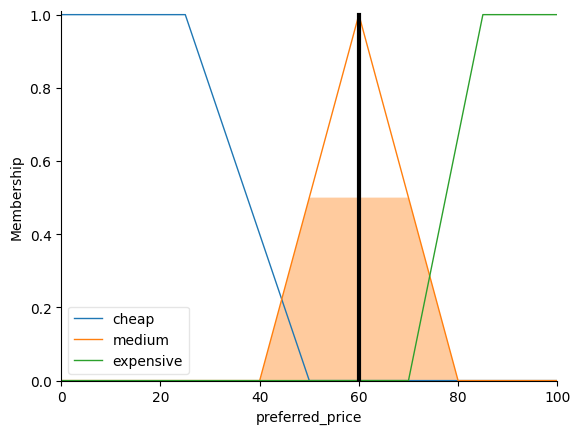

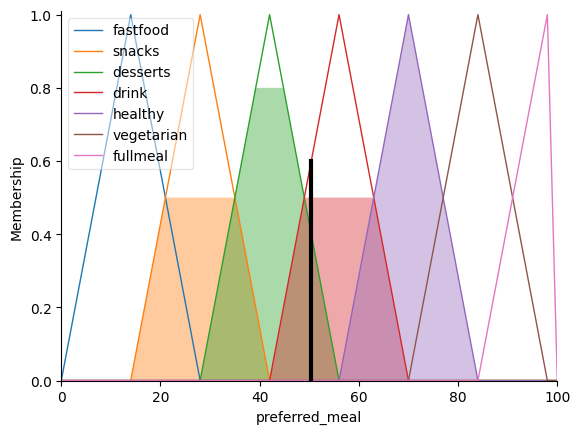

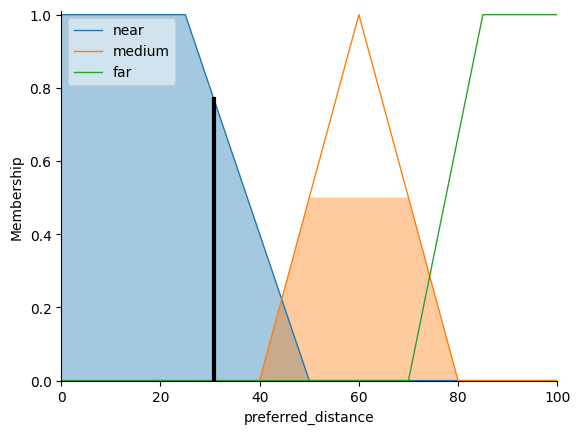

In [ ]:

# IMPORT
# =========================
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl

df = pd.read_excel("AI_dataset_HW_week2.xlsx")
df.columns = df.columns.str.strip()

df[["lat", "lon"]] = df["Tọa độ"].astype(str).str.split(",", expand=True)
df["lat"] = df["lat"].str.strip().astype(float)
df["lon"] = df["lon"].str.strip().astype(float)

# =========================
# FUZZY VARIABLES
# =========================
budget = ctrl.Antecedent(np.arange(0,1000001,1000),'budget')
hunger = ctrl.Antecedent(np.arange(1,11,0.1),'hunger')
time_available = ctrl.Antecedent(np.arange(0,181,1),'time_available')
weather = ctrl.Antecedent(np.arange(15,46,1),'weather')
health_goal = ctrl.Antecedent(np.arange(1,11,1),'health_goal')

preferred_price = ctrl.Consequent(np.arange(0,101,1),'preferred_price')
preferred_meal = ctrl.Consequent(np.arange(0,101,1),'preferred_meal')
preferred_distance = ctrl.Consequent(np.arange(0,101,1),'preferred_distance')

# =========================
# MEMBERSHIP FUNCTIONS
# =========================
budget['very_cheap'] = fuzz.trapmf(budget.universe,[0,0,20000,50000])
budget['cheap'] = fuzz.trimf(budget.universe,[50000,80000,120000])
budget['medium'] = fuzz.trimf(budget.universe,[100000,200000,300000])
budget['expensive'] = fuzz.trapmf(budget.universe,[280000,500000,1000000,1000000])

hunger['light'] = fuzz.trimf(hunger.universe,[1,3,5])
hunger['hungry'] = fuzz.trimf(hunger.universe,[4,6,8])
hunger['starving'] = fuzz.trapmf(hunger.universe,[7,8,10,10])

time_available['very_short'] = fuzz.trapmf(time_available.universe,[0,0,10,20])
time_available['short'] = fuzz.trimf(time_available.universe,[15,30,45])
time_available['medium'] = fuzz.trimf(time_available.universe,[40,70,100])
time_available['long'] = fuzz.trapmf(time_available.universe,[90,120,180,180])

weather['cold'] = fuzz.trapmf(weather.universe,[15,15,18,23])
weather['normal'] = fuzz.trimf(weather.universe,[22,27,32])
weather['hot'] = fuzz.trapmf(weather.universe,[30,35,45,45])

health_goal['diet'] = fuzz.trapmf(health_goal.universe,[1,1,2,3])
health_goal['balanced'] = fuzz.trimf(health_goal.universe,[2.5,4,6])
health_goal['bulking'] = fuzz.trapmf(health_goal.universe,[6,8,10,10])


# =========================
# OUTPUT VARIABLES
# =========================

preferred_price['cheap'] = fuzz.trapmf(preferred_price.universe,[0,0,25,50])
preferred_price['medium'] = fuzz.trimf(preferred_price.universe,[40,60,80])
preferred_price['expensive'] = fuzz.trapmf(preferred_price.universe,[70,85,100,100])

preferred_meal['fastfood'] = fuzz.trimf(preferred_meal.universe,[0,14,28])
preferred_meal['snacks'] = fuzz.trimf(preferred_meal.universe,[14,28,42])
preferred_meal['desserts'] = fuzz.trimf(preferred_meal.universe,[28,42,56])
preferred_meal['drink'] = fuzz.trimf(preferred_meal.universe,[42,56,70])
preferred_meal['healthy'] = fuzz.trimf(preferred_meal.universe,[56,70,84])
preferred_meal['vegetarian'] = fuzz.trimf(preferred_meal.universe,[70,84,98])
preferred_meal['fullmeal'] = fuzz.trimf(preferred_meal.universe,[84,98,100])

preferred_distance['near'] = fuzz.trapmf(preferred_distance.universe,[0,0,25,50])
preferred_distance['medium'] = fuzz.trimf(preferred_distance.universe,[40,60,80])
preferred_distance['far'] = fuzz.trapmf(preferred_distance.universe,[70,85,100,100])

# =========================
# PRICE PREFERENCE RULES
# =========================

rule1 = ctrl.Rule(budget['very_cheap'], preferred_price['cheap'])
rule2 = ctrl.Rule(budget['cheap'], preferred_price['cheap'])
rule3 = ctrl.Rule(budget['medium'], preferred_price['medium'])
rule4 = ctrl.Rule(budget['expensive'], preferred_price['expensive'])

# =========================
# HUNGER × TIME RULES
# =========================

rule5 = ctrl.Rule(hunger['light'] & time_available['very_short'], preferred_meal['drink'])
rule6 = ctrl.Rule(hunger['light'] & time_available['short'], preferred_meal['snacks'])
rule7 = ctrl.Rule(hunger['light'] & time_available['medium'], preferred_meal['desserts'])
rule8 = ctrl.Rule(hunger['light'] & time_available['long'], preferred_meal['desserts'])

rule9 = ctrl.Rule(hunger['hungry'] & time_available['very_short'], preferred_meal['snacks'])
rule10 = ctrl.Rule(hunger['hungry'] & time_available['short'], preferred_meal['snacks'])
rule11 = ctrl.Rule(hunger['hungry'] & time_available['medium'], preferred_meal['healthy'])
rule12 = ctrl.Rule(hunger['hungry'] & time_available['long'], preferred_meal['fullmeal'])

rule13 = ctrl.Rule(hunger['starving'] & time_available['very_short'], preferred_meal['fastfood'])
rule14 = ctrl.Rule(hunger['starving'] & time_available['short'], preferred_meal['fastfood'])
rule15 = ctrl.Rule(hunger['starving'] & time_available['medium'], preferred_meal['fullmeal'])
rule16 = ctrl.Rule(hunger['starving'] & time_available['long'], preferred_meal['fullmeal'])

# =========================
# BUDGET × HEALTH RULES
# =========================

rule17 = ctrl.Rule(budget['very_cheap'] & health_goal['diet'], preferred_meal['vegetarian'])
rule18 = ctrl.Rule(budget['very_cheap'] & health_goal['balanced'], preferred_meal['fullmeal'])
rule19 = ctrl.Rule(budget['very_cheap'] & health_goal['bulking'], preferred_meal['fastfood'])

rule20 = ctrl.Rule(budget['cheap'] & health_goal['diet'], preferred_meal['fullmeal'])
rule21 = ctrl.Rule(budget['cheap'] & health_goal['balanced'], preferred_meal['healthy'])
rule22 = ctrl.Rule(budget['cheap'] & health_goal['bulking'], preferred_meal['fastfood'])

rule23 = ctrl.Rule(budget['medium'] & health_goal['diet'], preferred_meal['healthy'])
rule24 = ctrl.Rule(budget['medium'] & health_goal['balanced'], preferred_meal['healthy'])
rule25 = ctrl.Rule(budget['medium'] & health_goal['bulking'], preferred_meal['fullmeal'])

rule26 = ctrl.Rule(budget['expensive'] & health_goal['diet'], preferred_meal['healthy'])
rule27 = ctrl.Rule(budget['expensive'] & health_goal['balanced'], preferred_meal['fullmeal'])
rule28 = ctrl.Rule(budget['expensive'] & health_goal['bulking'], preferred_meal['fullmeal'])

# =========================
# MEAL PREFERENCE RULES
# =========================

rule29 = ctrl.Rule(hunger['starving'] & budget['very_cheap'], preferred_meal['fastfood'])
rule30 = ctrl.Rule(hunger['starving'] & budget['cheap'], preferred_meal['fastfood'])
rule31 = ctrl.Rule(hunger['starving'] & budget['medium'], preferred_meal['fullmeal'])
rule32 = ctrl.Rule(hunger['starving'] & budget['expensive'], preferred_meal['fullmeal'])

rule33 = ctrl.Rule(hunger['hungry'] & budget['cheap'], preferred_meal['fastfood'])
rule34 = ctrl.Rule(hunger['hungry'] & budget['medium'], preferred_meal['healthy'])
rule35 = ctrl.Rule(hunger['hungry'] & budget['expensive'], preferred_meal['fullmeal'])

rule36 = ctrl.Rule(weather['hot'] & hunger['light'], preferred_meal['drink'])
rule37 = ctrl.Rule(weather['hot'] & hunger['hungry'], preferred_meal['desserts'])
rule38 = ctrl.Rule(weather['hot'] & hunger['starving'], preferred_meal['fastfood'])

rule39 = ctrl.Rule(weather['cold'] & hunger['light'], preferred_meal['snacks'])
rule40 = ctrl.Rule(weather['cold'] & hunger['hungry'], preferred_meal['fullmeal'])
rule41 = ctrl.Rule(weather['cold'] & hunger['starving'], preferred_meal['fullmeal'])

rule42 = ctrl.Rule(weather['normal'] & hunger['light'], preferred_meal['desserts'])
rule43 = ctrl.Rule(weather['normal'] & hunger['hungry'], preferred_meal['healthy'])
rule44 = ctrl.Rule(weather['normal'] & hunger['starving'], preferred_meal['fullmeal'])

rule45 = ctrl.Rule(health_goal['diet'], preferred_meal['healthy'])
rule46 = ctrl.Rule(health_goal['diet'] & weather['hot'], preferred_meal['vegetarian'])
rule47 = ctrl.Rule(health_goal['diet'] & hunger['light'], preferred_meal['vegetarian'])

rule48 = ctrl.Rule(health_goal['balanced'], preferred_meal['healthy'])
rule49 = ctrl.Rule(health_goal['balanced'] & hunger['starving'], preferred_meal['fullmeal'])

rule50 = ctrl.Rule(health_goal['bulking'], preferred_meal['fullmeal'])
rule51 = ctrl.Rule(health_goal['bulking'] & weather['hot'], preferred_meal['drink'])

rule52 = ctrl.Rule(weather['hot'] & time_available['very_short'], preferred_meal['drink'])
rule53 = ctrl.Rule(weather['hot'] & time_available['short'], preferred_meal['desserts'])

rule54 = ctrl.Rule(weather['cold'] & hunger['starving'] & time_available['long'], preferred_meal['fullmeal'])
rule55 = ctrl.Rule(weather['hot'] & hunger['light'] & time_available['very_short'], preferred_meal['drink'])
rule56 = ctrl.Rule(weather['hot'] & hunger['starving'] & time_available['short'], preferred_meal['fastfood'])

# =========================
# DISTANCE PREFERENCE RULES
# =========================

rule57 = ctrl.Rule(time_available['very_short'], preferred_distance['near'])
rule58 = ctrl.Rule(time_available['short'], preferred_distance['near'])
rule59 = ctrl.Rule(time_available['medium'], preferred_distance['medium'])
rule60 = ctrl.Rule(time_available['long'], preferred_distance['far'])

rule61 = ctrl.Rule(time_available['long'] & budget['expensive'], preferred_distance['far'])
rule62 = ctrl.Rule(hunger['starving'] & time_available['very_short'], preferred_distance['near'])
rule63 = ctrl.Rule(weather['hot'], preferred_distance['near'])
rule64 = ctrl.Rule(weather['normal'] & time_available['medium'], preferred_distance['medium'])
rule65 = ctrl.Rule(weather['cold'] & time_available['long'], preferred_distance['far'])
# =========================
# BUDGET × HUNGER RULES
# =========================

rule66 = ctrl.Rule(budget['very_cheap'] & hunger['light'], preferred_meal['snacks'])
rule67 = ctrl.Rule(budget['very_cheap'] & hunger['hungry'], preferred_meal['fastfood'])
rule68 = ctrl.Rule(budget['very_cheap'] & hunger['starving'], preferred_meal['fastfood'])

rule69 = ctrl.Rule(budget['cheap'] & hunger['light'], preferred_meal['snacks'])
rule70 = ctrl.Rule(budget['cheap'] & hunger['hungry'], preferred_meal['fastfood'])
rule71 = ctrl.Rule(budget['cheap'] & hunger['starving'], preferred_meal['fastfood'])

rule72 = ctrl.Rule(budget['medium'] & hunger['light'], preferred_meal['desserts'])
rule73 = ctrl.Rule(budget['medium'] & hunger['hungry'], preferred_meal['healthy'])
rule74 = ctrl.Rule(budget['medium'] & hunger['starving'], preferred_meal['fullmeal'])

rule75 = ctrl.Rule(budget['expensive'] & hunger['light'], preferred_meal['desserts'])
rule76 = ctrl.Rule(budget['expensive'] & hunger['hungry'], preferred_meal['healthy'])
rule77 = ctrl.Rule(budget['expensive'] & hunger['starving'], preferred_meal['fullmeal'])

# =========================
# BUDGET × HUNGER → PRICE RULES
# =========================

rule78 = ctrl.Rule(budget['very_cheap'] & hunger['light'], preferred_price['cheap'])
rule79 = ctrl.Rule(budget['very_cheap'] & hunger['hungry'], preferred_price['cheap'])
rule80 = ctrl.Rule(budget['very_cheap'] & hunger['starving'], preferred_price['cheap'])

rule81 = ctrl.Rule(budget['cheap'] & hunger['light'], preferred_price['cheap'])
rule82 = ctrl.Rule(budget['cheap'] & hunger['hungry'], preferred_price['cheap'])
rule83 = ctrl.Rule(budget['cheap'] & hunger['starving'], preferred_price['medium'])

rule84 = ctrl.Rule(budget['medium'] & hunger['light'], preferred_price['medium'])
rule85 = ctrl.Rule(budget['medium'] & hunger['hungry'], preferred_price['medium'])
rule86 = ctrl.Rule(budget['medium'] & hunger['starving'], preferred_price['expensive'])

rule87 = ctrl.Rule(budget['expensive'] & hunger['light'], preferred_price['expensive'])
rule88 = ctrl.Rule(budget['expensive'] & hunger['hungry'], preferred_price['expensive'])
rule89 = ctrl.Rule(budget['expensive'] & hunger['starving'], preferred_price['expensive'])

# =========================
# BUDGET × HUNGER → DISTANCE RULES
# =========================

rule90 = ctrl.Rule(budget['very_cheap'] & hunger['light'], preferred_distance['near'])
rule91 = ctrl.Rule(budget['very_cheap'] & hunger['hungry'], preferred_distance['near'])
rule92 = ctrl.Rule(budget['very_cheap'] & hunger['starving'], preferred_distance['near'])

rule93 = ctrl.Rule(budget['cheap'] & hunger['light'], preferred_distance['near'])
rule94 = ctrl.Rule(budget['cheap'] & hunger['hungry'], preferred_distance['medium'])
rule95 = ctrl.Rule(budget['cheap'] & hunger['starving'], preferred_distance['near'])

rule96 = ctrl.Rule(budget['medium'] & hunger['light'], preferred_distance['medium'])
rule97 = ctrl.Rule(budget['medium'] & hunger['hungry'], preferred_distance['medium'])
rule98 = ctrl.Rule(budget['medium'] & hunger['starving'], preferred_distance['medium'])

rule99 = ctrl.Rule(budget['expensive'] & hunger['light'], preferred_distance['far'])
rule100 = ctrl.Rule(budget['expensive'] & hunger['hungry'], preferred_distance['far'])
rule101 = ctrl.Rule(budget['expensive'] & hunger['starving'], preferred_distance['far'])


food_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4,rule78, rule79, rule80, rule81,rule82, rule83, rule84, rule85,rule86, rule87, rule88, rule89,

    # MEAL RULES
    rule5, rule6, rule7, rule8,
    rule9, rule10, rule11, rule12,
    rule13, rule14, rule15, rule16,

    rule17, rule18, rule19, rule20,
    rule21, rule22, rule23, rule24,
    rule25, rule26, rule27, rule28,

    rule29, rule30, rule31, rule32,
    rule33, rule34, rule35, rule36,
    rule37, rule38, rule39, rule40,
    rule41, rule42, rule43, rule44,
    rule45, rule46, rule47, rule48,
    rule49, rule50, rule51, rule52,
    rule53, rule54, rule55, rule56,

    rule66, rule67, rule68, rule69,
    rule70, rule71, rule72, rule73,
    rule74, rule75, rule76, rule77,

    # DISTANCE RULES
    rule57, rule58, rule59, rule60,
    rule61, rule62, rule63, rule64,
    rule65,

    rule90, rule91, rule92, rule93,
    rule94, rule95, rule96, rule97,
    rule98, rule99, rule100, rule101
])


food_simulation = ctrl.ControlSystemSimulation(food_ctrl)

food_simulation.input['budget'] = 150000
food_simulation.input['hunger'] = 2
food_simulation.input['time_available'] = 30
food_simulation.input['weather'] = 34
food_simulation.input['health_goal'] = 4

food_simulation.compute()

price_score = food_simulation.output['preferred_price']
meal_score = food_simulation.output['preferred_meal']
distance_score = food_simulation.output['preferred_distance']


print("Price Score:", price_score)
print("Meal Score:", meal_score)
print("Distance Score:", distance_score)

# WEIGHTED AVERAGE

price_weight = 0.3
meal_weight = 0.5
distance_weight = 0.2

final_recommendation_score = (
    (price_score * price_weight) +
    (meal_score * meal_weight) +
    (distance_score * distance_weight)
)
print("Final Recommendation Score:",
      final_recommendation_score)

# =========================
# RECOMMENDATION LEVEL
# =========================

if final_recommendation_score < 30:
    print("Recommendation Level: Weak")
elif final_recommendation_score < 50:
    print("Recommendation Level: Moderate")
elif final_recommendation_score < 70:
    print("Recommendation Level: Good")
else:
    print("Recommendation Level: Strong")

# VISUALIZE DEFUZZIFICATION
preferred_price.view(sim=food_simulation)
preferred_meal.view(sim=food_simulation)
preferred_distance.view(sim=food_simulation)


# CONVERT PRICE RANGE
def convert_price(price_text):
    if pd.isna(price_text):
        return np.nan
    price_text = str(price_text)
    price_text = re.sub(r'[^\d\-]', '', price_text)
    numbers = price_text.split('-')
    if len(numbers) == 2:
        low = int(numbers[0])
        high = int(numbers[1])
        return (low + high) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return np.nan
restaurants['avg_price'] = restaurants[
    'Giá Trung Bình / Người'
].apply(convert_price)

# ==========================================
# GET FUZZY OUTPUTS
# ==========================================

price_score = food_simulation.output[
    'preferred_price'
]
meal_score = food_simulation.output[
    'preferred_meal'
]
distance_score = food_simulation.output[
    'preferred_distance'
]
# ==========================================
# PRICE MEMBERSHIP FUNCTIONS
# ==========================================

price_universe = np.arange(0, 500001, 1000)

cheap_mf = fuzz.trapmf(
    price_universe,
    [0, 0, 50000, 100000]
)

medium_mf = fuzz.trimf(
    price_universe,
    [80000, 150000, 250000]
)

expensive_mf = fuzz.trapmf(
    price_universe,
    [200000, 300000, 500000, 500000]
)

# ==========================================
# USER PRICE PREFERENCE
# ==========================================

user_cheap = fuzz.interp_membership(
    np.arange(0,101,1),
    preferred_price['cheap'].mf,
    price_score
)

user_medium = fuzz.interp_membership(
    np.arange(0,101,1),
    preferred_price['medium'].mf,
    price_score
)

user_expensive = fuzz.interp_membership(
    np.arange(0,101,1),
    preferred_price['expensive'].mf,
    price_score
)

# BUDGET SIMILARITY
def calculate_budget_similarity(
    restaurant_price
):

    difference = abs(
        user_budget - restaurant_price
    )

    max_value = max(
        user_budget,
        restaurant_price
    )

    similarity = (
        1 - difference / max_value
    ) * 100

    similarity = max(0, similarity)

    return similarity

restaurants['budget_similarity'] = restaurants[
    'avg_price'
].apply(calculate_budget_similarity)

# USER MEAL PREFERENCE
preferred_meal_type = map_meal_type(
    meal_score
)
# ==========================================
# MEAL SIMILARITY
# ==========================================

def calculate_meal_similarity(
    restaurant_category
):

    restaurant_category = str(
        restaurant_category
    ).lower()

restaurants['meal_similarity'] = restaurants[
    'Subcategory 1'
].apply(calculate_meal_similarity)

# ==========================================
# DISTANCE SIMILARITY
# ==========================================

def calculate_distance_similarity(
    restaurant_price
):
    if user_budget < 80000:
        if restaurant_price < 80000:
            return 100
        return 40
    elif user_budget < 200000:
        return 70
    else:
        return 50
restaurants['distance_similarity'] = restaurants[
    'avg_price'
].apply(calculate_distance_similarity)

# ==========================================
# FINAL SCORE
# ==========================================

restaurants['restaurant_score'] = (
    restaurants['budget_similarity'] * 0.5 +
    restaurants['meal_similarity'] * 0.3 +
    restaurants['distance_similarity'] * 0.2
)
top_recommendations = restaurants.sort_values(
    by='restaurant_score',
    ascending=False
)

# DISPLAY
print(
    top_recommendations[
        [
            'Tên Nhà Hàng',
            'Giá Trung Bình / Người',
            'Subcategory 1',
            'budget_similarity',
            'meal_similarity',
            'distance_similarity',
            'restaurant_score'
        ]
    ].head(10)
)
